In [ ]:
!pip install palmerpenguins

In [ ]:
import numpy as np
import pandas as pd
from sys import exit
from palmerpenguins import load_penguins
from plotnine import ggplot, aes, geom_point, geom_bar

0\. Complete the [**check-in** from Section 6.3.2](https://ds-ml-with-python.github.io/Course-Textbook/05-function_writing.html#nested-environments-and-scope): Write a custom function that does the following:

Limit the penguins dataset to a user-chosen species and/or island.
Makes a scatterplot of the penguin bill length and depth.
Try writing a version of this function using dynamic lookup, and a version where everything the function needs is passed in directly

In [ ]:
penguins = load_penguins()
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


In [ ]:
# Version 1

def plot_bills_dynamic(species=None, island=None):
  df = penguins

  if species is not None:
    df = df[df["species"] == species]
  if island is not None:
    df = df[df["island"] == island]

  return (
        ggplot(df, aes(x="bill_length_mm", y="bill_depth_mm"))
        + geom_point()
    )

In [ ]:
# Version 2

def plot_bills(data, species=None, island=None):
    df = data

    if species is not None:
        df = df[df["species"] == species]
    if island is not None:
        df = df[df["island"] == island]

    return (
        ggplot(df, aes(x="bill_length_mm", y="bill_depth_mm"))
        + geom_point()
    )

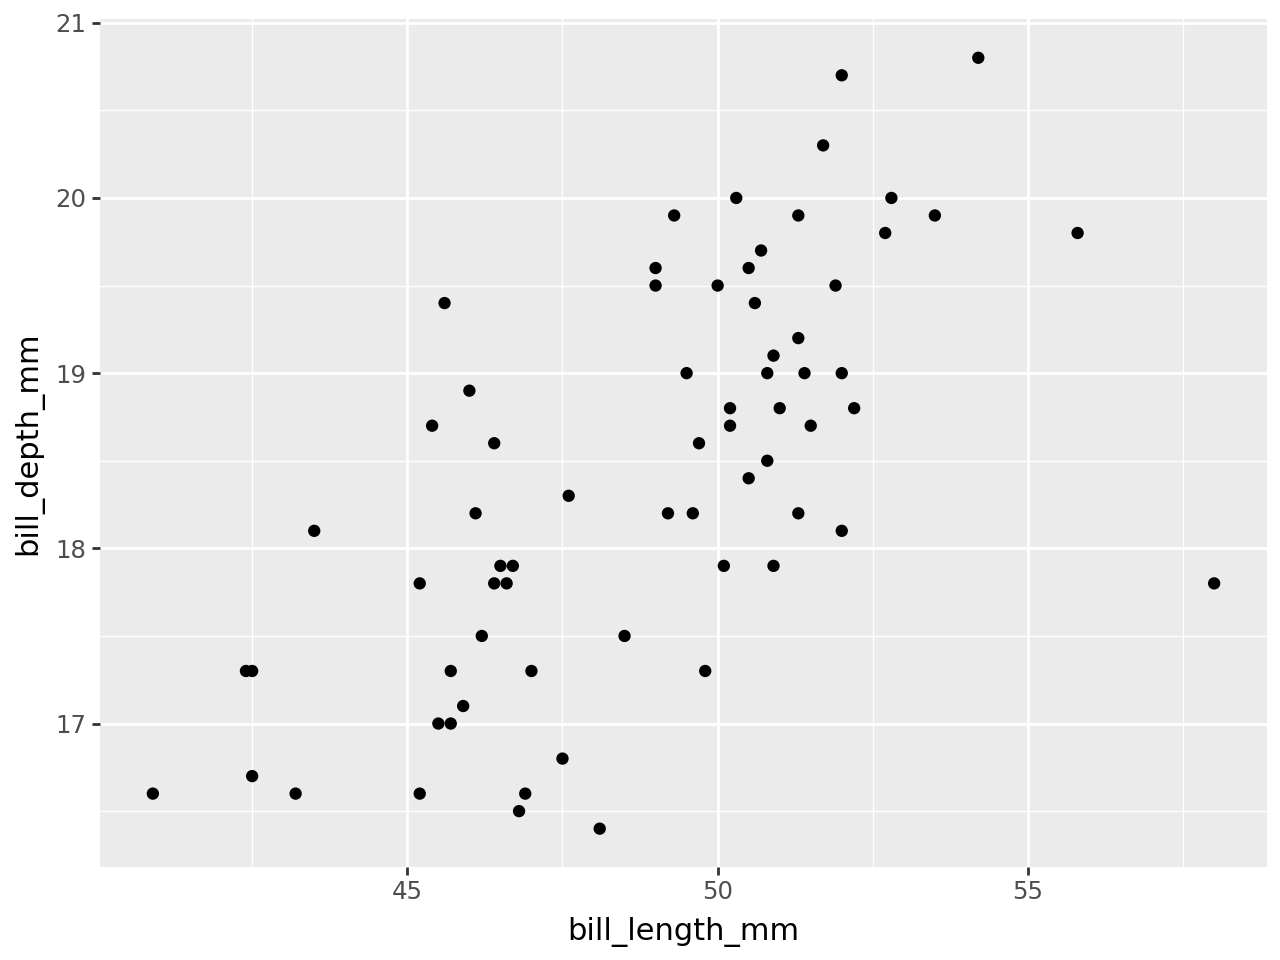

In [ ]:
plot_bills(penguins, species="Chinstrap", island="Dream")

/usr/local/lib/python3.13/dist-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 1 rows containing missing values.


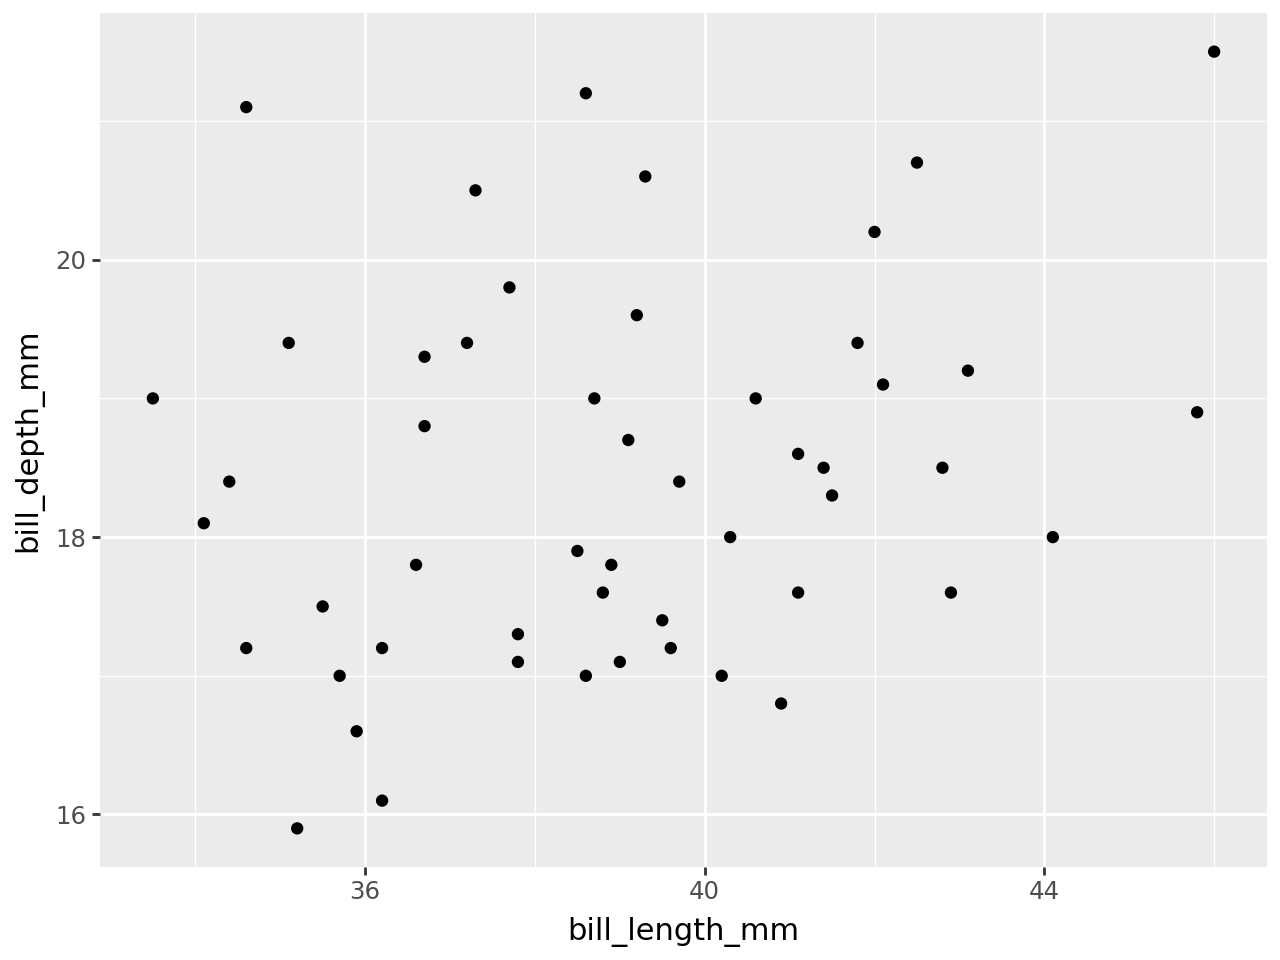

In [ ]:
plot_bills_dynamic(species="Adelie", island="Torgersen")

1. Fill in the necessary code to write a function called `times_seven()`. The function should take a single argument (`x`) and multiply the input by 7.
  + This function should check that the argument is numeric.
  + This function should also excitedly announce (print) *“I love sevens!”* if the argument to the function is a 7.

In [ ]:
def times_seven(x):

  if type(x) not in (int, float):
    exit("Input must be numeric")

  if x == 7:
    print("I love sevens")

  return x * 7

2. Write and run some *unit tests* for your `times_seven` function.  What happens if the input to the function is `[1, 3, 5, 7]`?

In [ ]:
print(times_seven(3))
print(times_seven(7))
print(times_seven(2.5))
print(times_seven("hi"))

21
I love sevens
49
17.5


SystemExit: Input must be numeric

In [ ]:
print(times_seven([1, 3, 5, 7]))

SystemExit: Input must be numeric

3. Consider the following function:

In [ ]:
def add_or_subtract(first_num, second_num = 2, type = "add"):

  if (type == "add"):
    res = first_num + second_num
  elif (type == "subtract"):
    res = first_num - second_num
  else:
    exit("Please choose `add` or `subtract` as the type.")

    return res

**Without running the code**, predict if the following will produce:

a. 1

b. -1

c. 30

d. An error defined by the function `add_or_subtract()`

e. An error defined in a different function, which is called inside the `add_or_subtract()` function

In [ ]:
print(add_or_subtract(5, 6, type = "subtract"))

print(add_or_subtract("orange"))

print(add_or_subtract(5, 6, type = "multiply"))

None


TypeError: can only concatenate str (not "int") to str

For the first function call, it would return None because the return statement is in the last else statement.

For the second one, it would return e (An error defined in a different function, which is called inside the add_or_subtract() function) because the function will try to add "orange" to 2 causing a TypeError.

For the third one, d (An error defined by the function add_or_subtract()) because there is no "multiply" operator so the function raises its own error.

4. Consider the following code:

In [ ]:
first_num  = 5
second_num = 3

result = 8

result = add_or_subtract(first_num, second_num = 4)

result_2 = add_or_subtract(first_num)


In your Global Environment, what is the value of...

a. `first_num`

b. `second_num`

c. `result`

d. `result_2`

a. 5. The function doesn't change the global.
b. 3. Passing second_num=4 sets only the function's local parameter.
c. None. The misindented return never runs. If it were fixed, it would be 9 (5 + 4).
d. None. Same reason. With the fix, it would be 7 (5 + the default 2).